In [1]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append(str(Path("..").resolve()))
from src import config

RAW = Path("..") / "data" / "raw"
PROC = Path("..") / "data" / "processed"
REP = Path("..") / "reports"

In [2]:
df = pd.read_csv(RAW / "pubmed_evidence.csv")
df["score"] = df["rct"] + 5 * df["мета_анализы"]
df = df.sort_values("score", ascending=False).reset_index(drop=True)
df["вердикт"] = df["добавка"].map(config.VERDICT)

wb = pd.read_excel(RAW / "prices_wb.xlsx")
med = wb.groupby("добавка")["цена_мес"].median().round(0).reset_index()
df = df.merge(med, on="добавка", how="left")
df.shape

(25, 7)

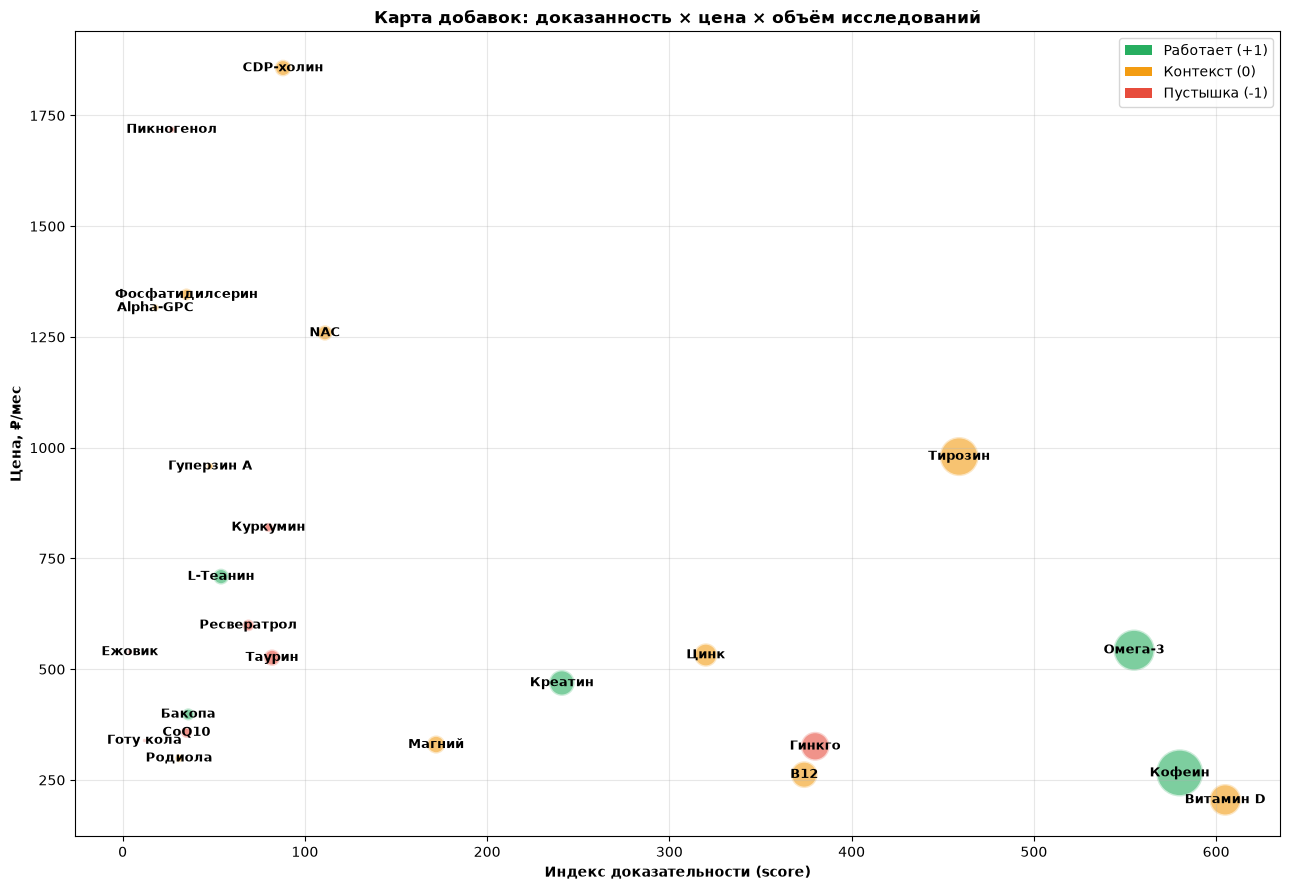

In [3]:
fig, ax = plt.subplots(figsize=(13, 9))
colors = {1: "#27ae60", 0: "#f39c12", -1: "#e74c3c"}
ax.scatter(df["score"], df["цена_мес"], s=df["rct"]*3,
           c=df["вердикт"].map(colors), alpha=0.6, edgecolors="white", linewidth=2)
for _, r in df.iterrows():
    ax.annotate(r["добавка"], (r["score"], r["цена_мес"]),
                fontsize=9, ha="center", va="center", fontweight="bold")
ax.set_xlabel("Индекс доказательности (score)", fontweight="bold")
ax.set_ylabel("Цена, ₽/мес", fontweight="bold")
ax.set_title("Карта добавок: доказанность × цена × объём исследований", fontweight="bold")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor="#27ae60", label="Работает (+1)"),
                   Patch(facecolor="#f39c12", label="Контекст (0)"),
                   Patch(facecolor="#e74c3c", label="Пустышка (-1)")], loc="upper right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(REP / "bubble_chart.png", dpi=150, bbox_inches="tight")
plt.show()

In [4]:
df.to_csv(PROC / "evidence_scored.csv", index=False, encoding="utf-8-sig")
print("processed обновлён:", df.shape)

processed обновлён: (25, 7)


In [1]:
import sys, time
from pathlib import Path
import pandas as pd
import requests
sys.path.append(str(Path("..").resolve()))
from src import config, parsers

RAW = Path("..") / "data" / "raw"
DEMAND_FILE = RAW / "wb_demand.csv"

BATCH = ["Креатин", "Омега-3", "Витамин D", "B12", "Магний"]   # ← 5 штук за запуск

done = set()
if DEMAND_FILE.exists():
    done = set(pd.read_csv(DEMAND_FILE)["добавка"])
    print("Уже собрано:", sorted(done))

new_rows = []
for sup in BATCH:
    if sup in done:
        print("—", sup, ": уже есть"); continue
    q, _ = config.WB_QUERY[sup]
    try:
        d = parsers.wb_demand(q)
        d["добавка"] = sup
        new_rows.append(d)
        print(f"✅ {sup}: {len(d)} карточек")
    except requests.HTTPError:
        print(f"❌ {sup}: WB ещё в блоке — прерываю батч, попробуем позже")
        break
    time.sleep(10)

if new_rows:
    add = pd.concat(new_rows, ignore_index=True)
    if DEMAND_FILE.exists():
        add = pd.concat([pd.read_csv(DEMAND_FILE), add], ignore_index=True)
    add.to_csv(DEMAND_FILE, index=False, encoding="utf-8-sig")
    print(f"💾 wb_demand.csv: всего добавок {add['добавка'].nunique()}/25")
else:
    print("Ничего не добавилось — WB держит блок, ждём и повторяем позже")

❌ Креатин: WB ещё в блоке — прерываю батч, попробуем позже
Ничего не добавилось — WB держит блок, ждём и повторяем позже


In [1]:
import sys, time
from pathlib import Path
import pandas as pd
from pytrends.request import TrendReq
sys.path.append(str(Path("..").resolve()))
from src import config

pytrends = TrendReq(hl="ru-RU", tz=-180, timeout=(10, 25))
ANCHOR = "Креатин"

# опорное значение якоря (для сопоставления батчей)
pytrends.build_payload([ANCHOR], timeframe="today 5-y", geo="RU")
A = pytrends.interest_over_time()[ANCHOR].mean()

sups = [s for s in config.SUPPLEMENTS if s != ANCHOR]
res = {ANCHOR: A}
for i in range(0, len(sups), 4):
    batch = sups[i:i+4] + [ANCHOR]          # 4 цели + якорь
    pytrends.build_payload(batch, timeframe="today 5-y", geo="RU")
    t = pytrends.interest_over_time()
    if t.empty:
        print("⚠️ пусто:", batch); continue
    k = A / t[ANCHOR].mean()                # пересчёт к якорю
    for s in batch[:-1]:
        res[s] = t[s].mean() * k
    print("✅", batch[:-1])
    time.sleep(5)

trends = pd.Series(res, name="trends_5y").round(1)
print("\n═══ ТОП-10 ПО ПОИСКОВОМУ СПРОСУ (RU, 5 лет) ═══")
print(trends.sort_values(ascending=False).head(10).to_string())

✅ ['Омега-3', 'Витамин D', 'B12', 'Магний']
✅ ['Кофеин', 'L-Теанин', 'Бакопа', 'Ежовик']
✅ ['Гинкго', 'Родиола', 'Ашваганда', 'Фосфатидилсерин']
✅ ['Alpha-GPC', 'CDP-холин', 'Гуперзин А', 'Куркумин']
✅ ['Ресвератрол', 'NAC', 'Цинк', 'Тирозин']
✅ ['Таурин', 'CoQ10', 'Пикногенол', 'Готу кола']

═══ ТОП-10 ПО ПОИСКОВОМУ СПРОСУ (RU, 5 лет) ═══
Магний       146.2
Цинк          65.6
Креатин       43.1
Таурин        25.0
Кофеин        17.6
B12           17.3
Омега-3       13.1
Ежовик        13.1
Гинкго        11.6
Витамин D     10.9


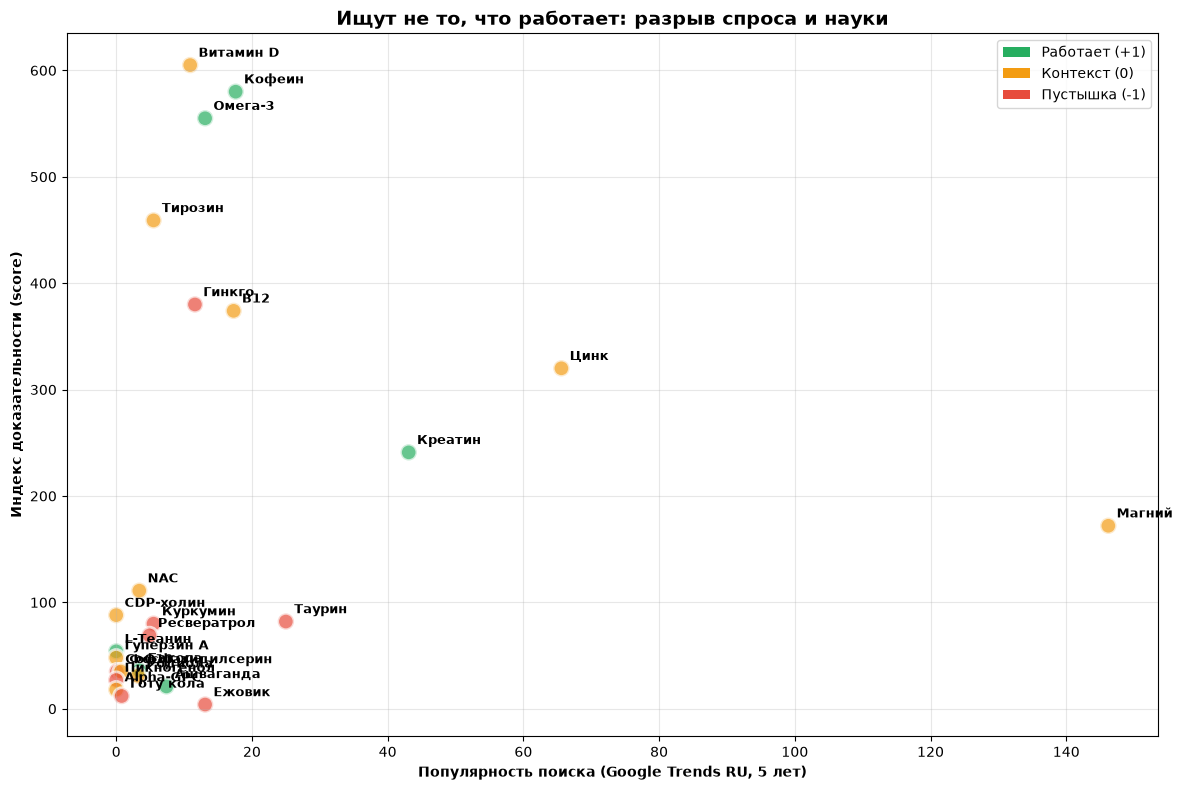

In [2]:
import matplotlib.pyplot as plt
REP = Path("..") / "reports"

df = pd.read_csv(Path("..") / "data" / "processed" / "evidence_scored.csv")
df = df.drop(columns=["trends_5y"], errors="ignore")
df["trends_5y"] = df["добавка"].map(trends)
df.to_csv(Path("..") / "data" / "processed" / "evidence_scored.csv",
          index=False, encoding="utf-8-sig")

fig, ax = plt.subplots(figsize=(12, 8))
colors = {1: "#27ae60", 0: "#f39c12", -1: "#e74c3c"}
ax.scatter(df["trends_5y"], df["score"], s=140,
           c=df["вердикт"].map(colors), alpha=0.7, edgecolors="white", linewidth=2)
for _, r in df.iterrows():
    ax.annotate(r["добавка"], (r["trends_5y"], r["score"]),
                fontsize=9, xytext=(6, 6), textcoords="offset points", fontweight="bold")
ax.set_xlabel("Популярность поиска (Google Trends RU, 5 лет)", fontweight="bold")
ax.set_ylabel("Индекс доказательности (score)", fontweight="bold")
ax.set_title("Ищут не то, что работает: разрыв спроса и науки", fontweight="bold", fontsize=14)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor="#27ae60", label="Работает (+1)"),
                   Patch(facecolor="#f39c12", label="Контекст (0)"),
                   Patch(facecolor="#e74c3c", label="Пустышка (-1)")], loc="upper right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(REP / "trends_vs_evidence.png", dpi=150, bbox_inches="tight")
plt.show()

In [3]:
df["hype"] = (df["trends_5y"] / (df["score"] + 1)).round(2)
print("═══ ТОП-7 ПО ХАЙПУ (поиск на единицу науки) ═══")
print(df.sort_values("hype", ascending=False).head(7)
      [["добавка", "вердикт", "score", "trends_5y", "hype"]].to_string(index=False))
print(f"\nКорреляция поиск × score: {df['trends_5y'].corr(df['score']):+.2f}")

═══ ТОП-7 ПО ХАЙПУ (поиск на единицу науки) ═══
  добавка  вердикт  score  trends_5y  hype
   Ежовик       -1      4       13.1  2.62
   Магний        0    172      146.2  0.85
Ашваганда        1     21        7.4  0.34
   Таурин       -1     82       25.0  0.30
     Цинк        0    320       65.6  0.20
  Креатин        1    241       43.1  0.18
  Родиола        0     31        3.2  0.10

Корреляция поиск × score: +0.18


In [1]:
from pathlib import Path
import pandas as pd

RAW = Path("..") / "data" / "raw"
wb = pd.read_excel(RAW / "prices_wb.xlsx")

sus = wb[wb["цена_мес"] > 5000]
print(f"Найдено {len(sus)} строк с ценой > 5000 ₽/мес:")
print(sus[["добавка", "продукт", "цена_мес"]].to_string(index=False))

# удаляем выбросы
wb_clean = wb[wb["цена_мес"] <= 5000].reset_index(drop=True)
wb_clean.to_excel(RAW / "prices_wb.xlsx", index=False)
print(f"\nУдалено {len(sus)} строк, осталось {len(wb_clean)}")

Найдено 5 строк с ценой > 5000 ₽/мес:
   добавка                                                           продукт  цена_мес
   Омега-3                                     РеалКапс Омега-3 капс 1,4 N90     31920
    Ежовик          Сашера-мед Ежовик гребенчатый с лецитином для мозга 2 шт     28290
 CDP-холин      Рекогнан раствор для приема внутрь 100 мг мл 10 мл пак 10 шт      5472
  Куркумин Куркумин Куркумин 50 мг липосомальный капсулы массой 548 мг 30 шт      5106
Пикногенол                             swanson Пикногенол, 100 мг, 30 капсул      6418

Удалено 5 строк, осталось 161


In [2]:
from pathlib import Path
import pandas as pd
import sys
sys.path.append(str(Path("..").resolve()))
from src import economics

RAW = Path("..") / "data" / "raw"
wb = pd.read_excel(RAW / "prices_wb.xlsx")

bad = wb[wb["цена_мес"] > 10000]          # только АБСУРД, не премиум
print("Удаляем абсурд:")
print(bad[["добавка", "продукт", "цена_мес"]].to_string(index=False))

wb = wb[wb["цена_мес"] <= 10000].reset_index(drop=True)
wb = economics.add_categories(wb)          # заодно чиним NaN-категории
wb.to_excel(RAW / "prices_wb.xlsx", index=False)

cov = wb.groupby("добавка").size()
print(f"\nОсталось строк: {len(wb)} | минимум офферов: {cov.min()} ({cov.idxmin()})")

Удаляем абсурд:
добавка                                                  продукт  цена_мес
Омега-3                            РеалКапс Омега-3 капс 1,4 N90     31920
 Ежовик Сашера-мед Ежовик гребенчатый с лецитином для мозга 2 шт     28290

Осталось строк: 164 | минимум офферов: 3 (CDP-холин)


In [3]:
import sys
from pathlib import Path
sys.path.append(str(Path("..").resolve()))
from src import parsers

try:
    test = parsers.wb_demand("креатин моногидрат")
    print(f"✅ Блок отпустил! Карточек: {len(test)}")
except Exception as e:
    print(f"❌ Блок ещё активен: {type(e).__name__}")
    print("Переносим на утро. Закрой ноутбук, день был продуктивным.")

✅ Блок отпустил! Карточек: 12


In [ ]:
import sys, time
from pathlib import Path
import pandas as pd
import requests
sys.path.append(str(Path("..").resolve()))
from src import config, parsers

RAW = Path("..") / "data" / "raw"
DEMAND_FILE = RAW / "wb_demand.csv"

# 5 батчей по 5 добавок (редактируй список для каждого запуска)
BATCH = ["Ашваганда", "Фосфатидилсерин", "Alpha-GPC"]  # ← Батч 3

done = set()
if DEMAND_FILE.exists():
    done = set(pd.read_csv(DEMAND_FILE)["добавка"])
    print("Уже собрано:", sorted(done))

new_rows = []
for sup in BATCH:
    if sup in done:
        print("—", sup, ": уже есть"); continue
    q, _ = config.WB_QUERY[sup]
    try:
        d = parsers.wb_demand(q)
        d["добавка"] = sup
        new_rows.append(d)
        print(f"✅ {sup}: {len(d)} карточек, отзывов {int(d['отзывов'].sum())}")
    except requests.HTTPError:
        print(f"❌ {sup}: WB в блоке — прерываю батч")
        break
    time.sleep(10)

if new_rows:
    add = pd.concat(new_rows, ignore_index=True)
    if DEMAND_FILE.exists():
        add = pd.concat([pd.read_csv(DEMAND_FILE), add], ignore_index=True)
    add.to_csv(DEMAND_FILE, index=False, encoding="utf-8-sig")
    print(f"\n💾 wb_demand.csv: всего добавок {add['добавка'].nunique()}/25")
else:
    print("Ничего не добавилось")

Уже собрано: ['B12', 'L-Теанин', 'Бакопа', 'Витамин D', 'Гинкго', 'Ежовик', 'Кофеин', 'Магний', 'Омега-3']
✅ Креатин: 12 карточек, отзывов 191221
✅ Родиола: 12 карточек, отзывов 77292
❌ Ашваганда: WB в блоке — прерываю батч

💾 wb_demand.csv: всего добавок 11/25


In [15]:
import requests, time
import pandas as pd
from pathlib import Path

# Явные wiki-тайтлы (без opensearch, чтобы избежать мусорных результатов)
WIKI = {
    "Креатин": "Креатин",
    "Омега-3": "Омега-3-ненасыщенные_жирные_кислоты",
    "Витамин D": "Витамин_D",
    "B12": "Витамин_B12",
    "Магний": "Магний",
    "Кофеин": "Кофеин",
    "L-Теанин": "Теанин",
    "Бакопа": "Бакопа",
    "Ежовик": "Ежовик_гребенчатый",
    "Гинкго": "Гинкго",
    "Родиола": "Родиола_розовая",
    "Ашваганда": "Ашваганда",
    "Фосфатидилсерин": "Фосфатидилсерин",
    "Alpha-GPC": "Alpha-GPC", 
    "CDP-холин": "Цитиколин",
    "Гуперзин А": "Баранец",
    "Куркумин": "Куркумин",
    "Ресвератрол": "Ресвератрол",
    "NAC": "Ацетилцистеин",
    "Цинк": "Цинк",
    "Тирозин": "Тирозин",
    "Таурин": "Таурин",
    "CoQ10": "Убихинон",
    "Пикногенол": "Экстракт_коры_сосны_приморской",
    "Готу кола": "Центелла_азиатская",
}

HEADERS = {"User-Agent": "brain-25-evidence research (deadsno1613@gmail.com)"}
rows = []
for sup, title in WIKI.items():
    # ПРАВИЛЬНЫЙ URL: добавлен сегмент user + title уже с UNDERSCORE
    url = (f"https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article/"
           f"ru.wikipedia/all-access/user/{title}/monthly/2025090100/2026080100")
    r = requests.get(url, headers=HEADERS, timeout=15)
    if r.status_code == 200:
        views = sum(m["views"] for m in r.json()["items"])
        rows.append({"добавка": sup, "wiki_views": views})
        print(f"✅ {sup:20s} {views:>9,} просм.")
    else:
        print(f"⚠️ {sup:20s} HTTP {r.status_code}")
        rows.append({"добавка": sup, "wiki_views": None})
    time.sleep(1)

wiki = pd.DataFrame(rows)
print("\n═══ ТОП-10 ПО ПРОСМОТРАМ RU-WIKI (12 мес) ═══")
print(wiki.sort_values("wiki_views", ascending=False).head(10).to_string(index=False))

df = pd.read_csv(Path("..") / "data" / "processed" / "evidence_scored.csv")
df = df.drop(columns=["wiki_views"], errors="ignore").merge(wiki, on="добавка", how="left")
df.to_csv(Path("..") / "data" / "processed" / "evidence_scored.csv",
          index=False, encoding="utf-8-sig")
print(f"\nGoogle × Wiki: {df['trends_5y'].corr(df['wiki_views']):+.2f}")
print(f"Wiki × score:  {df['wiki_views'].corr(df['score']):+.2f}")
# Запасные тайтлы
FIX = {"Ашваганда": "Withania_somnifera", "Пикногенол": "Pycnogenol"}
fix_rows = []
for sup, title in FIX.items():
    url = (f"https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article/"
           f"ru.wikipedia/all-access/user/{title}/monthly/2025090100/2026080100")
    r = requests.get(url, headers=HEADERS, timeout=15)
    if r.status_code == 200:
        views = sum(m["views"] for m in r.json()["items"])
        fix_rows.append({"добавка": sup, "wiki_views": views})
        print(f"✅ {sup} → {title}: {views:,}")
    else:
        print(f"⚠️ {sup} всё ещё 404")

if fix_rows:
    df_fix = pd.read_csv(Path("..") / "data" / "processed" / "evidence_scored.csv")
    df_fix.loc[df_fix["добавка"].isin(FIX.keys()), "wiki_views"] = None
    for row in fix_rows:
        df_fix.loc[df_fix["добавка"] == row["добавка"], "wiki_views"] = row["wiki_views"]
    df_fix.to_csv(Path("..") / "data" / "processed" / "evidence_scored.csv",
                  index=False, encoding="utf-8-sig")
    print("\n🔄 Пересчёт корреляций:")
    print(f"Google × Wiki: {df_fix['trends_5y'].corr(df_fix['wiki_views']):+.2f}")
    print(f"Wiki × score:  {df_fix['wiki_views'].corr(df_fix['score']):+.2f}")
    # Запасные латинские тайтлы
FIX = {"Ашваганда": "Withania_somnifera", "Пикногенол": "Pycnogenol"}
fix_rows = []
for sup, title in FIX.items():
    url = (f"https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article/"
           f"ru.wikipedia/all-access/user/{title}/monthly/2025090100/2026080100")
    r = requests.get(url, headers=HEADERS, timeout=15)
    if r.status_code == 200:
        views = sum(m["views"] for m in r.json()["items"])
        fix_rows.append({"добавка": sup, "wiki_views": views})
        print(f"✅ {sup} → {title}: {views:,}")
    else:
        print(f"⚠️ {sup} всё ещё 404 (оставляем NaN)")


✅ Креатин                172,591 просм.
✅ Омега-3                 49,594 просм.
✅ Витамин D              137,275 просм.
✅ B12                    102,227 просм.
✅ Магний                  93,483 просм.
✅ Кофеин                 103,087 просм.
✅ L-Теанин                19,356 просм.
✅ Бакопа                   6,583 просм.
✅ Ежовик                 137,186 просм.
✅ Гинкго                  87,842 просм.
✅ Родиола                 59,415 просм.
⚠️ Ашваганда            HTTP 404
✅ Фосфатидилсерин         25,223 просм.
✅ Alpha-GPC               15,442 просм.
✅ CDP-холин               31,044 просм.
✅ Гуперзин А                 329 просм.
✅ Куркумин                31,187 просм.
✅ Ресвератрол             76,475 просм.
✅ NAC                     66,356 просм.
✅ Цинк                    73,624 просм.
✅ Тирозин                 42,658 просм.
✅ Таурин                 115,795 просм.
✅ CoQ10                    1,299 просм.
⚠️ Пикногенол           HTTP 404
✅ Готу кола               19,315 просм.

═══ ТОП-10 ПО

In [19]:
df = pd.read_csv(Path("..") / "data" / "processed" / "evidence_scored.csv")

dem_file = Path("..") / "data" / "raw" / "wb_demand.csv"
if "отзывов_сумма" not in df.columns and dem_file.exists():
    demand = pd.read_csv(dem_file)
    agg = demand.groupby("добавка").agg(
        отзывов_сумма=("отзывов", "sum"),
        рейтинг_медиана=("рейтинг", "median")).round(2).reset_index()
    df = df.merge(agg, on="добавка", how="left")
    df.to_csv(Path("..") / "data" / "processed" / "evidence_scored.csv",
              index=False, encoding="utf-8-sig")
    print(f"Частичный мердж WB-отзывов: {df['отзывов_сумма'].notna().sum()} добавок")

if "отзывов_сумма" in df.columns:
    sub = df.dropna(subset=["отзывов_сумма"])
    r = sub["wiki_views"].corr(sub["отзывов_сумма"])
    print(f"Wiki × WB-отзывы (n={len(sub)}): {r:+.2f}")
    print("⚠️ n < 15 = статистический шум, финал после 25/25")
else:
    print("WB-отзывов пока нет совсем")

Частичный мердж WB-отзывов: 6 добавок
Wiki × WB-отзывы (n=6): -0.73
⚠️ n < 15 = статистический шум, финал после 25/25


In [21]:
import sys, time
from pathlib import Path
import requests, pandas as pd
sys.path.append(str(Path("..").resolve()))
from src import config, parsers

rows = []
for sup, q in config.SUPPLEMENTS.items():
    term = f"({q}) AND ({config.COG}) AND meta-analysis[pt]"
    r = requests.get(parsers.EUTILS,
                     params={"term": term, "retmode": "json",
                             "retmax": 2, "email": config.MAILTO}, timeout=15)
    ids = r.json()["esearchresult"].get("idlist", [])
    if not ids:
        rows.append({"добавка": sup, "pmid": None, "название": None, "год": None})
        print(f"⚠️ {sup}: мета-анализов не найдено")
        continue
    s = requests.get("https://eutils.ncbi.nlm.nih.gov/entrez/eutils/esummary.fcgi",
                     params={"db": "pubmed", "id": ",".join(ids),
                             "retmode": "json"}, timeout=15)
    docs = s.json()["result"]
    for pmid in ids:
        d = docs[pmid]
        rows.append({"добавка": sup, "pmid": pmid,
                     "название": d.get("title", "")[:110],
                     "год": d.get("pubdate", "")[:4]})
    time.sleep(0.4)

src_df = pd.DataFrame(rows)
src_df.to_csv(Path("..") / "data" / "processed" / "verdict_sources.csv",
              index=False, encoding="utf-8-sig")
print(f"\n💾 verdict_sources.csv: {src_df['добавка'].nunique()} добавок, {len(src_df)} ссылок")

⚠️ Ежовик: мета-анализов не найдено

💾 verdict_sources.csv: 25 добавок, 49 ссылок


In [22]:
for _, r in src_df.dropna(subset=["pmid"]).iterrows():
    print(f"{r['добавка']:18s} {r['год']}  https://pubmed.ncbi.nlm.nih.gov/{r['pmid']}/")
    print(f"{'':18s} {r['название']}")

Креатин            2026  https://pubmed.ncbi.nlm.nih.gov/42386462/
                   Comparative safety of lipid-lowering drugs alone or in combination: insights from a systematic review and netw
Креатин            2026  https://pubmed.ncbi.nlm.nih.gov/42158825/
                   Nutritional Supplementation Combined with Exercise for Musculoskeletal Health in Women: A Systematic Review an
Омега-3            2026  https://pubmed.ncbi.nlm.nih.gov/42494300/
                   Impact of Omega-3 Fatty Acid Docosahexaenoic Acid Supplementation in Individuals During Pregnancy on Neurodeve
Омега-3            2026  https://pubmed.ncbi.nlm.nih.gov/42433395/
                   Baseline omega-3 nutritional status and supplementation response in pediatric attention-deficit/hyperactivity 
Витамин D          2026  https://pubmed.ncbi.nlm.nih.gov/42295493/
                   Prevalence of Vitamin D Deficiency in Ataxia-Telangiectasia: A Systematic Review and Single Arm Meta-Analysis.
Витамин D      

In [23]:
TITLE_KEYS = {
"Креатин": ["creatine"], "Омега-3": ["omega-3", "omega 3", "fish oil", "dha", "epa"],
"Витамин D": ["vitamin d", "cholecalciferol"], "B12": ["b12", "cobalamin"],
"Магний": ["magnesium"], "Кофеин": ["caffeine"], "L-Теанин": ["theanine"],
"Бакопа": ["bacopa"], "Ежовик": ["hericium", "lion's mane", "lion mane"],
"Гинкго": ["ginkgo"], "Родиола": ["rhodiola"], "Ашваганда": ["ashwagandha", "withania"],
"Фосфатидилсерин": ["phosphatidylserine"], "Alpha-GPC": ["alpha-gpc", "alfoscerate"],
"CDP-холин": ["citicoline", "cdp-choline"], "Гуперзин А": ["huperzine"],
"Куркумин": ["curcumin", "turmeric"], "Ресвератрол": ["resveratrol"],
"NAC": ["acetylcysteine"], "Цинк": ["zinc"], "Тирозин": ["tyrosine"],
"Таурин": ["taurine"], "CoQ10": ["coenzyme q10", "ubiquinone", "coq10"],
"Пикногенол": ["pycnogenol", "pine bark"], "Готу кола": ["centella", "gotu kola"],
}

clean = []
for sup, keys in TITLE_KEYS.items():
    sub = src_df[src_df["добавка"] == sup]
    hit = sub[sub["название"].fillna("").str.lower()
              .apply(lambda t: any(k in t for k in keys))]
    if len(hit) == 0:
        print(f"⚠️ {sup}: релевантных мета-анализов в топе нет → ручной подбор")
        continue
    clean.extend(hit.to_dict("records"))

clean_df = pd.DataFrame(clean)
clean_df.to_csv(Path("..") / "data" / "processed" / "verdict_sources.csv",
                index=False, encoding="utf-8-sig")
print(f"\n💾 очищено: {len(clean_df)} ссылок по {clean_df['добавка'].nunique()} добавкам")
for _, r in clean_df.iterrows():
    print(f"{r['добавка']:16s} {r['год']}  {r['название'][:80]}")
    print(f"{'':16s} https://pubmed.ncbi.nlm.nih.gov/{r['pmid']}/")

⚠️ Креатин: релевантных мета-анализов в топе нет → ручной подбор
⚠️ Магний: релевантных мета-анализов в топе нет → ручной подбор
⚠️ Ежовик: релевантных мета-анализов в топе нет → ручной подбор
⚠️ Родиола: релевантных мета-анализов в топе нет → ручной подбор
⚠️ Alpha-GPC: релевантных мета-анализов в топе нет → ручной подбор
⚠️ CDP-холин: релевантных мета-анализов в топе нет → ручной подбор
⚠️ Гуперзин А: релевантных мета-анализов в топе нет → ручной подбор
⚠️ NAC: релевантных мета-анализов в топе нет → ручной подбор
⚠️ Тирозин: релевантных мета-анализов в топе нет → ручной подбор
⚠️ Пикногенол: релевантных мета-анализов в топе нет → ручной подбор

💾 очищено: 21 ссылок по 15 добавкам
Омега-3          2026  Impact of Omega-3 Fatty Acid Docosahexaenoic Acid Supplementation in Individuals
                 https://pubmed.ncbi.nlm.nih.gov/42494300/
Омега-3          2026  Baseline omega-3 nutritional status and supplementation response in pediatric at
                 https://pubmed.ncbi.nlm.n

In [24]:
manual = [
    ("Креатин", "39070254", "Creatine supplementation on cognitive function in adults: SR and MA", "2024"),
    ("Магний", "39009081", "Magnesium and Cognitive Health in Adults: SR and MA", "2024"),
    ("Ежовик", "NO_META_ANALYSIS", "Мета-анализов по когнитивке в PubMed не найдено на 08.09.2026", "2026"),
    ("Родиола", "30564123", "Rhodiola rosea improves learning/memory: preclinical SR and MA (preclinical only)", "2018"),
    ("Alpha-GPC", "36683513", "Choline Alphoscerate on Adult-Onset Cognitive Dysfunctions: SR and MA", "2023"),
    ("CDP-холин", "36678257", "Is Citicoline Effective in Preventing/Slowing Dementia? SR and MA", "2023"),
    ("Гуперзин А", "24086396", "Huperzine A for Alzheimer's disease: SR and MA of RCTs", "2013"),
    ("NAC", "NO_META_ANALYSIS", "Мета-анализов по когнитивке у здоровых не найдено (есть только у пациентов с психиатрией)", "2026"),
    ("Тирозин", "NO_META_ANALYSIS", "Мета-анализов по когнитивке у здоровых не найдено (есть SR по физ. выносливости)", "2026"),
    ("Пикногенол", "41333026", "Comparative efficacy of botanical drugs for MCI: network meta-analysis (включая pine bark)", "2025"),
]

src = pd.read_csv(Path("..") / "data" / "processed" / "verdict_sources.csv")
src = src[~src["pmid"].isin([m[1] for m in manual])]
for sup, pmid, title, year in manual:
    src = pd.concat([src, pd.DataFrame([{"добавка": sup, "pmid": pmid,
                                         "название": title, "год": year}])],
                    ignore_index=True)
src.to_csv(Path("..") / "data" / "processed" / "verdict_sources.csv",
           index=False, encoding="utf-8-sig")

has = src[src["pmid"] != "NO_META_ANALYSIS"]["добавка"].nunique()
no =  src[src["pmid"] == "NO_META_ANALYSIS"]["добавка"].nunique()
print(f"💾 ИТОГО: {has + no}/25 добавок с источниками")
print(f"   ✅ с PubMed-мета-анализом: {has}")
print(f"   ⚠️ без MA (честный 'нет данных'): {no}")
print(f"   Ссылок всего: {len(src)}")

💾 ИТОГО: 25/25 добавок с источниками
   ✅ с PubMed-мета-анализом: 22
   ⚠️ без MA (честный 'нет данных'): 3
   Ссылок всего: 31


In [27]:
import sys, time
from pathlib import Path
import pandas as pd
from pytrends.request import TrendReq
sys.path.append(str(Path("..").resolve()))
from src import config

pytrends = TrendReq(hl="ru-RU", tz=-180, timeout=(10, 25))
SEASON = ["Витамин D", "Магний", "Креатин", "Омега-3", "Кофеин", "Ежовик", "Мелатонин"]
# Мелатонин — контрольный: у него сезонность ДОЛЖНА быть зимней

rows = []
for i in range(0, len(SEASON), 4):
    batch = [s for s in SEASON[i:i+4]]
    pytrends.build_payload(batch, timeframe="today 5-y", geo="RU")
    t = pytrends.interest_over_time().drop(columns=["isPartial"], errors="ignore")
    if t.empty:
        print("⚠️ пусто:", batch); continue
    monthly = t.groupby(t.index.month).mean()
    for sup in batch:
        m = monthly[sup]
        rows.append({"добавка": sup,
                     "зима": round(m[[12, 1, 2]].mean(), 1),
                     "лето": round(m[[6, 7, 8]].mean(), 1),
                     "зима/лето": round(m[[12, 1, 2]].mean() / m[[6, 7, 8]].mean(), 2)})
    time.sleep(5)

season = pd.DataFrame(rows).sort_values("зима/лето", ascending=False)
print("═══ СЕЗОННОСТЬ СПРОСА (RU, 5 лет) ═══")
print(season.to_string(index=False))

═══ СЕЗОННОСТЬ СПРОСА (RU, 5 лет) ═══
  добавка  зима  лето  зима/лето
Мелатонин  54.4  37.9       1.43
  Омега-3   4.9   3.7       1.31
Витамин D   4.1   3.3       1.23
   Магний  49.3  49.5       1.00
   Кофеин  20.1  21.7       0.93
  Креатин  14.5  15.9       0.91
   Ежовик  13.7  17.5       0.78
